# Testing distance scaling on synthetic data
Due to the lack of ground truth comparisons when it comes to the bulk data, we need synthetic data to test the function's ability to differentiate between close and far away contacts. For this purpose, we will create a function to generate some synthetic data for which we can reason whether maps should be similar or not, and test the OT with the distance scaling function on this data.

## Imports

In [5]:
# Enabling Fast Reload 
%load_ext autoreload
%autoreload 2

# Imports
import sys
import numpy as np
import matplotlib.pyplot as plt
sys.path.append('/Users/oliviersmeets/Desktop/University/Master Internship 1/Data Handling/Scripts')
from hicvisutils import hic_vis_matrix
from hicdatautils import hic_ot_source_to_targets, dist_weights

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Helper Functions

In [49]:
def generate_single_cloud_matrix(size: int, dist: int, intensity: int=1000, width: int= None,
                                    height: int=None, center_index: int=None):
    '''
        Generates a synthethic contact map with a single point cloud at a fixed distance
        from the diagonal.

        Parameters
        ----------
        size : int
            Size of the contact map (size x size).
        dist : int
            Distance of the center of the point cloud from the major diagonal.
        intensity : int
            Maximum value of reads within the point cloud.
            Default = 1000.
        width : int
            The width of the point cloud along the targeted diagonal.
            Default = None, calculated based on cloud size.
        height : int
            The height of the point cloud across diagonals.
            Default = None, calculated based on cloud size.
        center_index : int
            The index of the center of the point cloud on the given diagonal.
            Default = None, uses middle of given diagonal.
        
        Returns
        -------
        matrix : np.ndarray
            Symmetric synthetic contact map.
    '''
    # Value errors
    if dist < 0 or dist >= size:
        raise ValueError(f"dist is not within matrix size (dist={dist}, allowed values: 0 - {size-1})")
    if center_index is not None and (center_index < 0 or center_index >= (size - dist)):
        raise ValueError(f"center_index is not within range allowed for given dist (center_index={center_index}, allowed values: 0 - {size-dist})")
    if (width is not None and width < 0) or (height is not None and height < 0):
        raise ValueError(f"Point cloud width and height must be higher than 0 (height={height}, width={width})")

    # Set center_index
    if center_index is None:
        center_index = (size - dist)/2
    
    i0 = center_index
    j0 = center_index + dist

    # Set cloud size
    if width is None:
        width = max(1, size // 20)
    if height is None:
        height = max(1, size // 80)
    
    sigma_width = width / 2
    sigma_height = height / 2

    # Defining coordinate grid
    x, y = np.meshgrid(np.arange(size), np.arange(size), indexing="ij")

    dx = x - i0
    dy = y - j0

    # Rotate onto diagonal
    u_width = (dx + dy) / np.sqrt(2)
    u_height = (dx - dy) / np.sqrt(2)

    # Gaussian blob for point cloud
    blob = intensity * np.exp(
        -(u_width**2 / (2 * sigma_width**2) 
        + u_height**2 / (2 * sigma_height**2))
    )

    # Make matrix symmetrical
    matrix = blob + blob.T

    # Ensure integers
    matrix = np.rint(matrix).astype(int)

    return matrix

## Single point cloud tests

### Varying dist
Here, we would expect to see barely any change in OT cost as normalization means the masses examined by OT should be fairly similar.

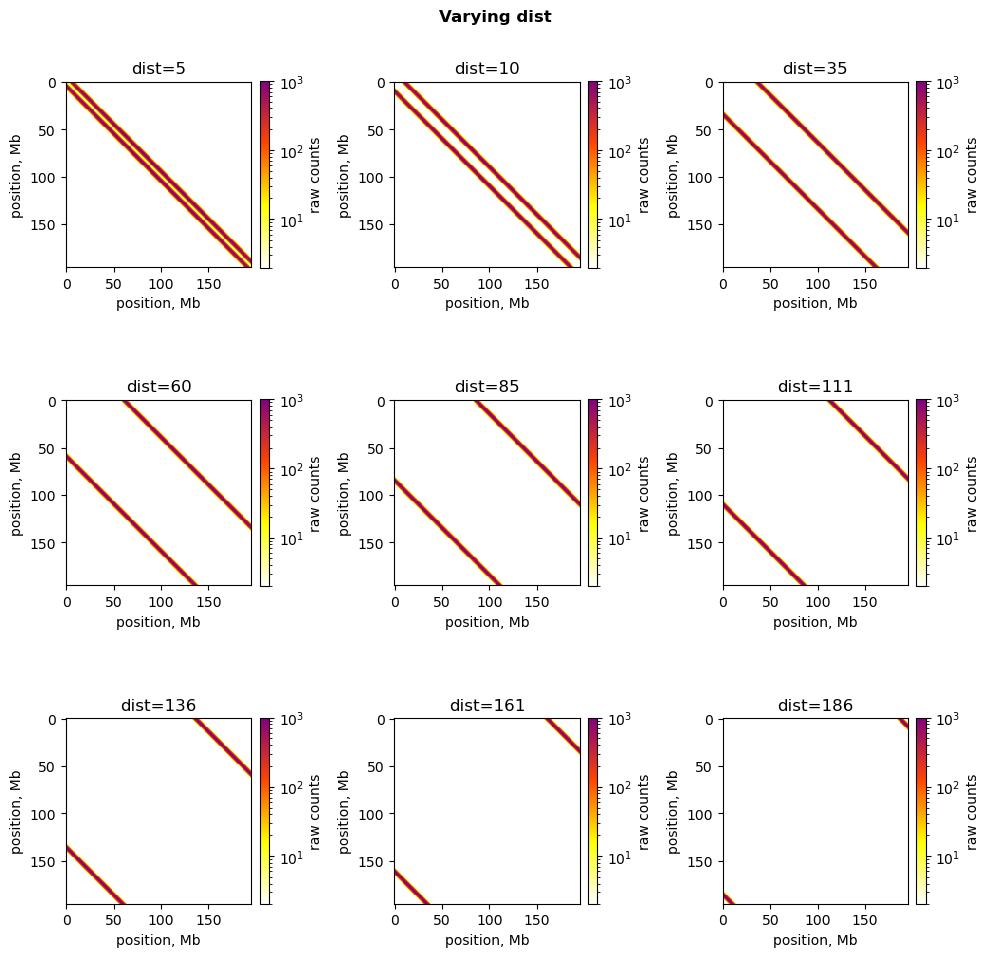

In [53]:
### Generating and plotting data ###
    # Settings parameters
n = 196
ref_dist = 5
w = n*2
h=2

spacing = np.linspace(0.05, 0.95, 8)
percentages = spacing * 100
target_dists = np.round(spacing * n)

    # Generating reference
ref_map = generate_single_cloud_matrix(size=n, dist=ref_dist, width=w, height=h)


    # Visualizing
fig, axs = plt.subplots(3, 3, figsize=(10, 10))

axes_flatten = axs.flatten()
hic_vis_matrix(ref_map, f"dist={ref_dist}", cmap="higlass", ax=axes_flatten[0])

target_maps = []
for ax, d in zip(axes_flatten[1:], target_dists):
    target_map = generate_single_cloud_matrix(size=n, dist=d, width=w, height=h)
    hic_vis_matrix(target_map, f"dist={d:.0f}", cmap="higlass", ax=ax)
    target_maps.append(target_map)

plt.suptitle("Varying dist", fontweight="bold")
plt.tight_layout()

In [ ]:
### Performing OT ###
    # Unscaled
dist_ot_unscaled = hic_ot_source_to_targets(ref_map, target_maps, norm='sum')

    # Distance scaled
scaled_maps = []
scaled_ref = dist_weights(ref_map, gamma=2.0)
for map in target_maps:
    scaled_maps.append(dist_weights(map, gamma=2.0))
dist_ot_scaled = hic_ot_source_to_targets(scaled_ref, scaled_maps, norm='sum')

[16.25633313768966, 577.3011959962329, 1949.139709518317, 4141.914028572575, 7301.090072312302, 11188.776428144462, 15909.91024752702, 21437.728259431828]
[14.14000545070682, 553.6580591034588, 1902.1986988242184, 4071.3963061138566, 7205.896074408463, 11069.802201059136, 15767.026268307332, 21270.95188345535]


Text(0.5, 1.0, 'OT loss ratio for varying dist')

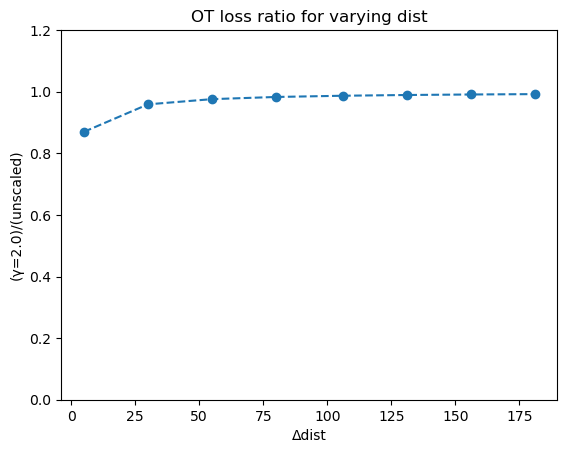

In [ ]:
### Graphing Results ###
dist_ratios = np.asarray(target_dists) - ref_dist
dist_ot_ratios = np.asarray(dist_ot_scaled)/np.asarray(dist_ot_unscaled)

plt.plot(dist_ratios, dist_ot_ratios, marker="o", linestyle="--")
plt.xlabel("Δdist")
plt.ylabel("(γ=2.0)/(unscaled)")
plt.ylim(bottom=0, top=1.2)
plt.title("OT loss ratio for varying dist")

These results make sense. While I hadn't thought about it before hand, the results being lower on for the scaled data at lower distances is due to the scaling function 'removing' mass from the data, meaning the target dataset seems more similar as there is less mass to transport. This effect decreases with distance as the scaling comes closer to 1.0.

### Varying width
Width only influences the number of points on a single diagonal. Thus, distance scaling is expected to have minimal effects.

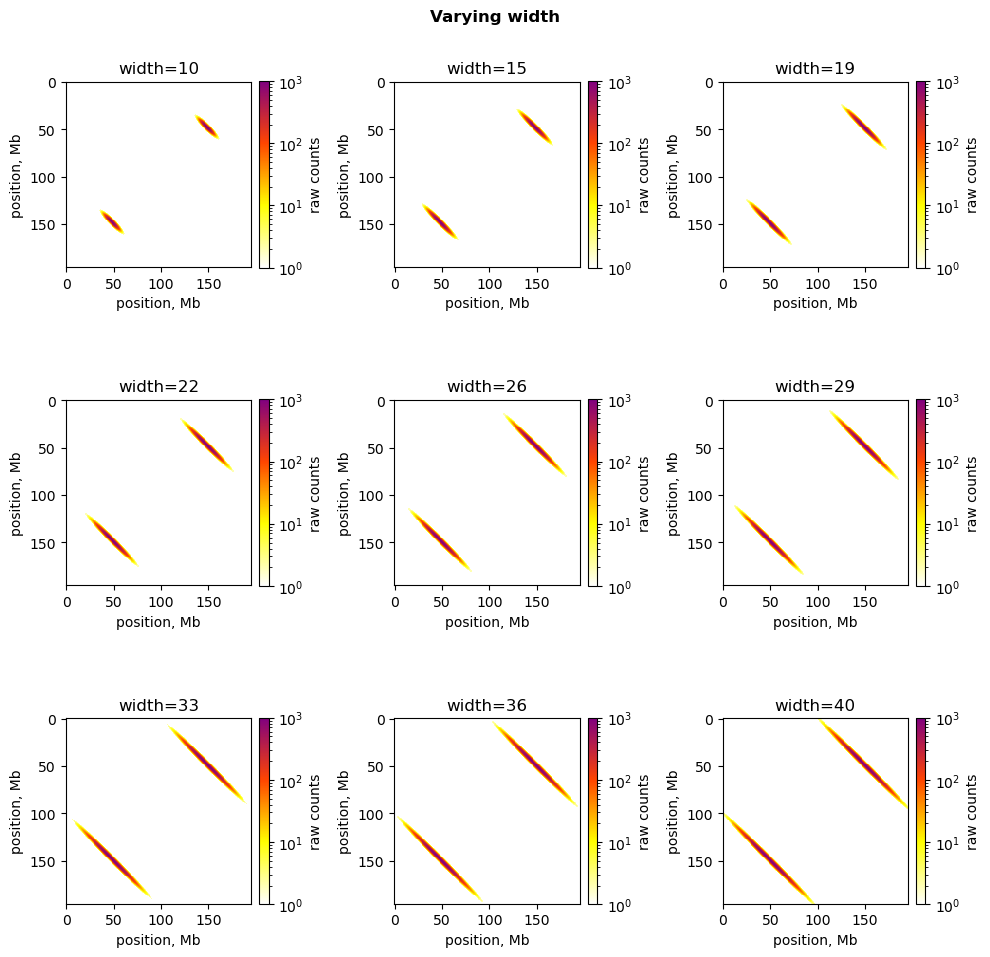

In [54]:
### Generating and plotting data ###
# Settings parameters
n = 196
d = 100
ref_width = 10
h=2

spacing = np.linspace(1.5, 4, 8)
target_widths = np.round(spacing * ref_width)

    # Generating reference
ref_map = generate_single_cloud_matrix(size=n, dist=d, width=ref_width, height=h)


    # Visualizing
fig, axs = plt.subplots(3, 3, figsize=(10, 10))

axes_flatten = axs.flatten()
hic_vis_matrix(ref_map, f"width={ref_width}", cmap="higlass", ax=axes_flatten[0])

target_maps = []
for ax, w in zip(axes_flatten[1:], target_widths):
    target_map = generate_single_cloud_matrix(size=n, dist=d, width=w, height=h)
    hic_vis_matrix(target_map, f"width={w:.0f}", cmap="higlass", ax=ax)
    target_maps.append(target_map)

plt.suptitle("Varying width", fontweight="bold")
plt.tight_layout()

In [ ]:
### Performing OT ###
width_ot_unscaled = hic_ot_source_to_targets(ref_map, target_maps, norm='sum')

    # Distance scaled
scaled_maps = []
scaled_ref = dist_weights(ref_map, gamma=2.0)
for map in target_maps:
    scaled_maps.append(dist_weights(map, gamma=2.0))
width_ot_scaled = hic_ot_source_to_targets(scaled_ref, scaled_maps, norm='sum')

[6.585458976683924, 20.655379567753574, 36.3161625313731, 64.24138301719816, 90.42757523301691, 132.36844217650017, 168.79801621827633, 222.8041665384567]
[6.585444344154769, 20.655360353731766, 36.31607692102041, 64.24125809794356, 90.42747216102302, 132.3682213821224, 168.79673836548915, 222.7973386812708]


Text(0.5, 1.0, 'OT loss ratio for varying width')

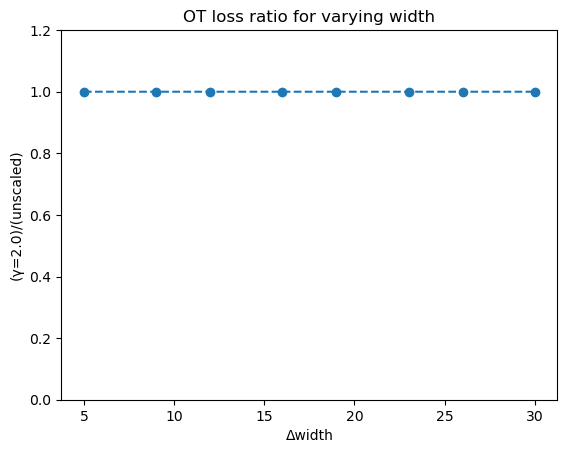

In [26]:
### Graphing Results ###
width_ratios = np.asarray(target_widths) - ref_width
width_ot_ratios = np.asarray(width_ot_scaled)/np.asarray(width_ot_unscaled)

plt.plot(width_ratios, width_ot_ratios, marker="o", linestyle="--")
plt.xlabel("Δwidth")
plt.ylabel("(γ=2.0)/(unscaled)")
plt.ylim(bottom=0, top=1.2)
plt.title("OT loss ratio for varying width")

The results completely match the hypothesis.

### Varying height
Since height determines which diagonals the data spans, this should result in much higher OT costs with varying height for the scaled data compared to the unscaled data.

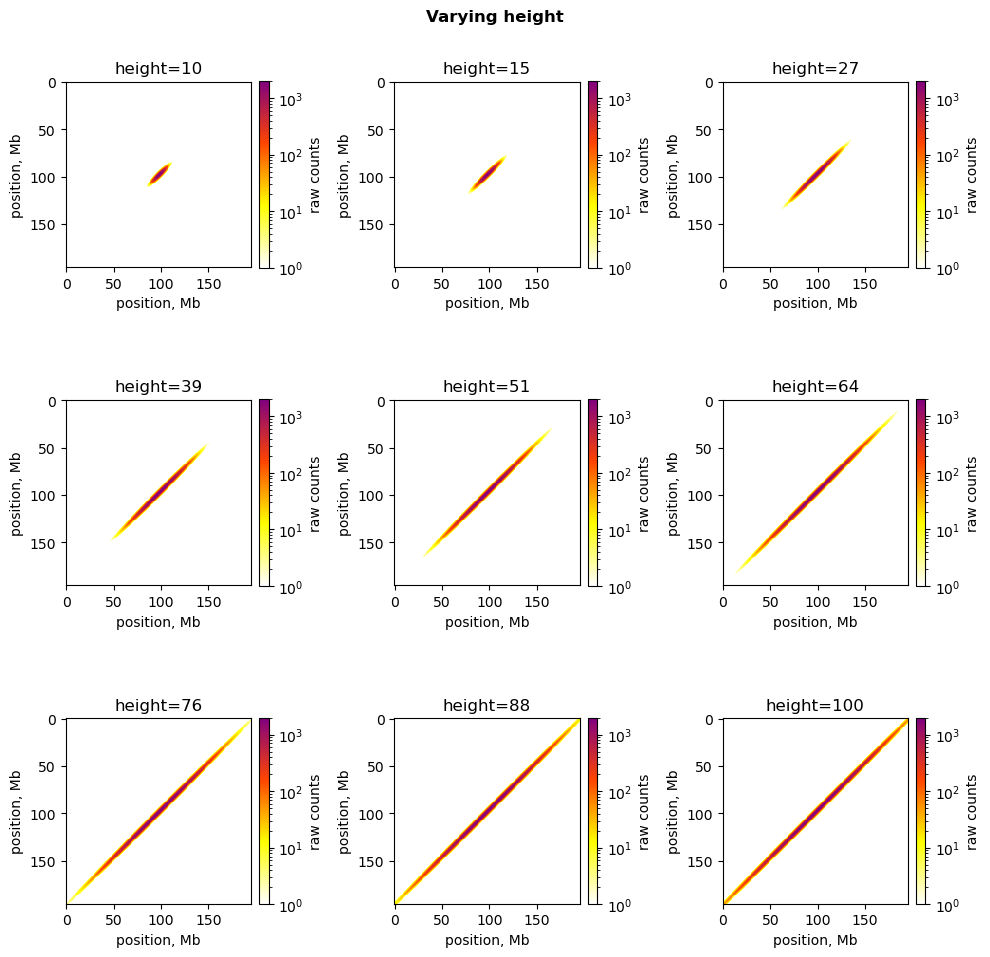

In [55]:
### Generating and plotting data ###
# Settings parameters
n = 196
d = 0
w = 2
ref_height= 10

spacing = np.linspace(1.5, 10, 8)
target_heights = np.round(spacing * ref_height)

    # Generating reference
ref_map = generate_single_cloud_matrix(size=n, dist=d, width=w, height=ref_height)


    # Visualizing
fig, axs = plt.subplots(3, 3, figsize=(10, 10))

axes_flatten = axs.flatten()
hic_vis_matrix(ref_map, f"height={ref_height}", cmap="higlass", ax=axes_flatten[0])

target_maps = []
for ax, h in zip(axes_flatten[1:], target_heights):
    target_map = generate_single_cloud_matrix(size=n, dist=d, width=w, height=h)
    hic_vis_matrix(target_map, f"height={h:.0f}", cmap="higlass", ax=ax)
    target_maps.append(target_map)

plt.suptitle("Varying height", fontweight="bold")
plt.tight_layout()

In [102]:
### Performing OT ###
height_ot_unscaled = hic_ot_source_to_targets(ref_map, target_maps, norm='sum')

    # Distance scaled
scaled_maps = []
scaled_ref = dist_weights(ref_map, gamma=2.0)
for map in target_maps:
    scaled_maps.append(dist_weights(map, gamma=2.0))
height_ot_scaled = hic_ot_source_to_targets(scaled_ref, scaled_maps, norm='sum')

Text(0.5, 1.0, 'OT loss ratio for varying height')

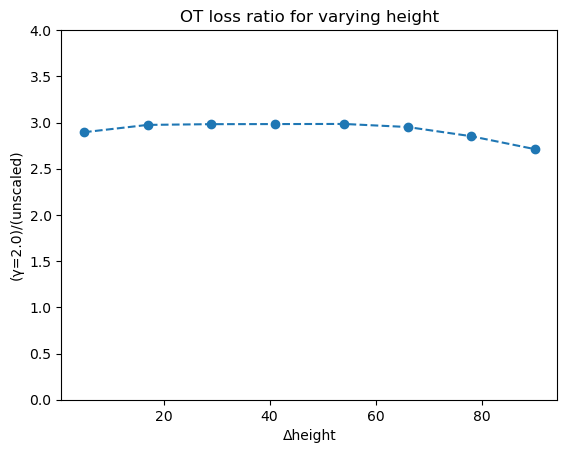

In [48]:
### Graphing Results ###
height_ratios = np.asarray(target_heights) - ref_height
height_ot_ratios = np.asarray(height_ot_scaled)/np.asarray(height_ot_unscaled)

plt.plot(height_ratios, height_ot_ratios, marker="o", linestyle="--")
plt.xlabel("Δheight")
plt.ylabel("(γ=2.0)/(unscaled)")
plt.ylim(bottom=0, top=4.0)
plt.title("OT loss ratio for varying height")

## Two point cloud tests

### Simple Test
Here, we will just test two comparisons between source and target:
- Source: wide band on the major diagonal, small diagonal band
- Target: wide band on the major diagonal/wide band on the major diagonal, small diagonal band at different location
For "normal" OT, the cost should be very similar between the two. Scaled OT should be better at differentiating

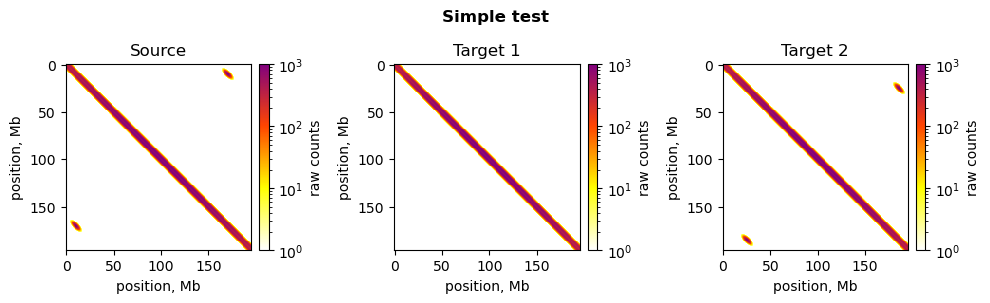

In [167]:
### Creating maps ###
n = 196
dist_near = 2
dist_far = 160
w_near = 200
w_far = 5
int_far = 100
source_ci = 10
target_ci = 25
g = 1.0

    # Source map
major = generate_single_cloud_matrix(size=n, dist=dist_near, width=w_near)
source_far = generate_single_cloud_matrix(size=n, dist=dist_far, width=w_far, center_index=source_ci)
source_map = major + source_far

    # Target map
target_far = generate_single_cloud_matrix(size=n, dist=dist_far, width=w_far, center_index=target_ci)
target_map = major + target_far
target_maps = [major, target_map]

    # Visualizing
fig, axs = plt.subplots(1, 3, figsize=(10, 3))
axes_flatten = axs.flatten()
hic_vis_matrix(source_map, "Source", ax=axes_flatten[0], cmap='higlass')
hic_vis_matrix(major, "Target 1", ax=axes_flatten[1], cmap='higlass')
hic_vis_matrix(target_map, "Target 2", ax=axes_flatten[2], cmap='higlass')

plt.suptitle("Simple test", fontweight="bold")
plt.tight_layout()

In [169]:
### Performing OT ###
    # Unscaled
simp_ot_unscaled = hic_ot_source_to_targets(source_map, target_maps, norm='sum')

    # Distance scaled
scaled_maps = []
scaled_ref = dist_weights(source_map, gamma=g)
for map in target_maps:
    scaled_maps.append(dist_weights(map, gamma=g))
simp_ot_scaled = hic_ot_source_to_targets(scaled_ref, scaled_maps, norm='sum')
print(simp_ot_unscaled)
print(simp_ot_scaled)

[400.75836597321893, 14.639786650752491]
[10709.10797969474, 314.3645755841845]


In [173]:
### Calculating refined statistic ###
unscaled_abs_dif = (simp_ot_unscaled[0] - simp_ot_unscaled[1])
scaled_abs_dif = (simp_ot_scaled[0] - simp_ot_scaled[1])
unscaled_rel_dif = unscaled_abs_dif/simp_ot_unscaled[1]
scaled_rel_dif = scaled_abs_dif/simp_ot_scaled[1]
print(unscaled_abs_dif)
print(scaled_abs_dif)
print(unscaled_rel_dif)
print(scaled_rel_dif)

386.1185793224664
10394.743404110555
26.374604257133743
33.06588658977869


### Shifting the second point cloud
Should show drastically increasing OT cost for scaled compared to not scaled.

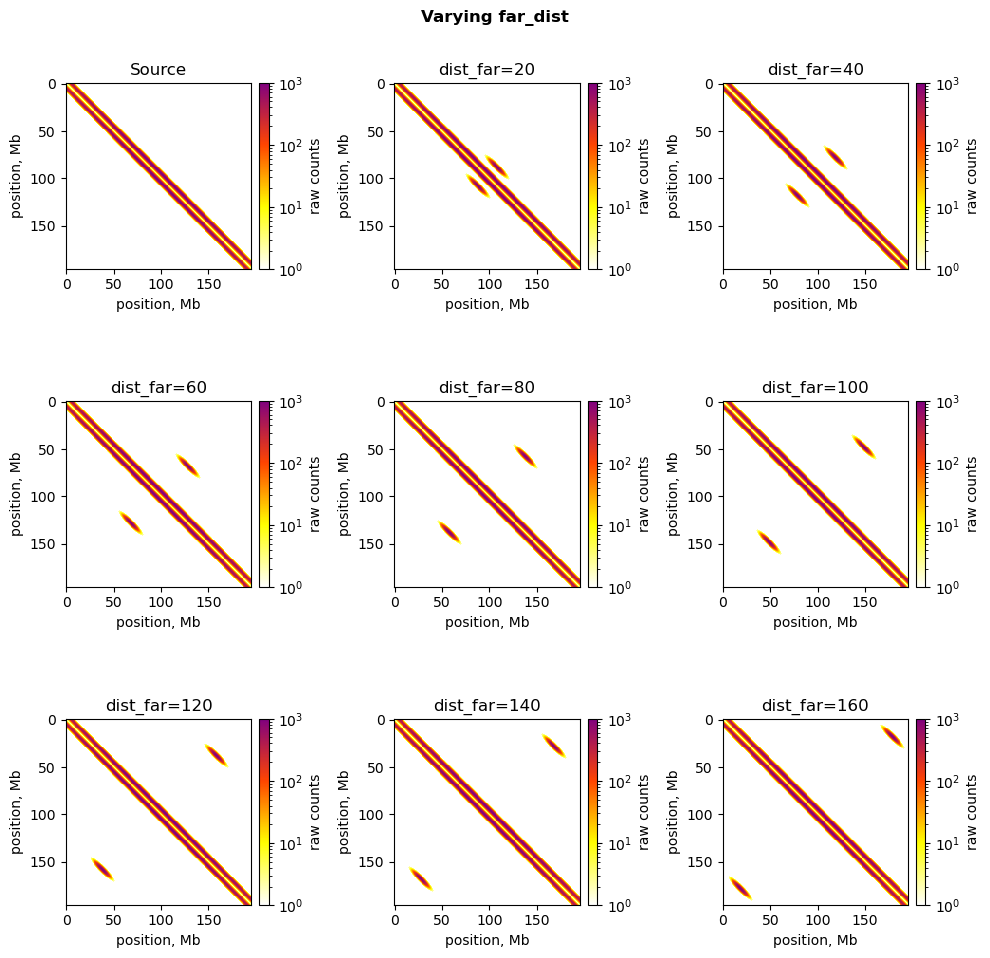

In [ ]:
    # Settings parameters
n = 196
dist_near = 5
ref_dist_far = 20
w_near = 200
w_far = 10
g = 4

spacing = np.linspace(20, 160, 8)
target_dists_far = np.round(spacing)

    # Generating reference
near_map = generate_single_cloud_matrix(size=n, dist=dist_near, width=w_near)

    # Visualizing
fig, axs = plt.subplots(3, 3, figsize=(10, 10))

axes_flatten = axs.flatten()
hic_vis_matrix(near_map, f"Source", cmap="higlass", ax=axes_flatten[0])

target_maps = []
for ax, d in zip(axes_flatten[1:], target_dists_far):
    target_map = near_map + generate_single_cloud_matrix(size=n, dist=d, width=w_far)
    hic_vis_matrix(target_map, f"dist_far={d:.0f}", cmap="higlass", ax=ax)
    target_maps.append(target_map)

plt.suptitle("Varying far_dist", fontweight="bold")
plt.tight_layout()

In [153]:
### Performing OT ###
    # Unscaled
dist_far_ot_unscaled = hic_ot_source_to_targets(near_map, target_maps, norm='sum')

    # Distance scaled
scaled_maps = []
scaled_ref = dist_weights(near_map, gamma=g)
for map in target_maps:
    scaled_maps.append(dist_weights(map, gamma=g))
dist_far_ot_scaled = hic_ot_source_to_targets(scaled_ref, scaled_maps, norm='sum')
print(dist_far_ot_unscaled)
print(dist_far_ot_scaled)

[17.261064279392453, 44.11446463804001, 93.76417927271088, 166.2738005066133, 261.6605712072274, 379.9299990690933, 521.0827022185048, 685.1240314549996]
[3397.471744781469, 4556.613624117867, 5476.036696231504, 6758.124221459221, 8434.34074955557, 10509.040585099317, 12983.2160421316, 15857.168007176302]


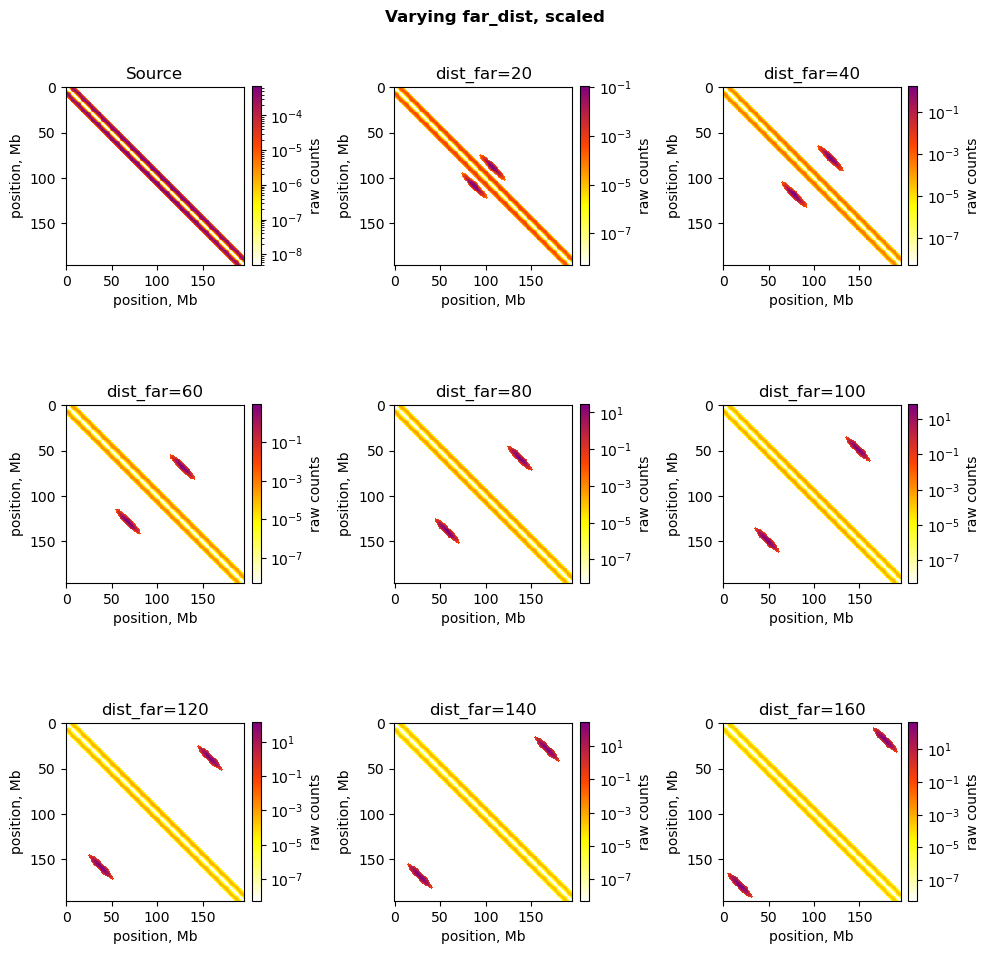

In [154]:
### Graphing scaled maps ###
fig, axs = plt.subplots(3, 3, figsize=(10, 10))

axes_flatten = axs.flatten()
hic_vis_matrix(scaled_ref, f"Source", cmap="higlass", ax=axes_flatten[0])

for ax, map, d in zip(axes_flatten[1:], scaled_maps, target_dists_far):
    hic_vis_matrix(map, f"dist_far={d:.0f}", cmap="higlass", ax=ax)
    target_maps.append(target_map)

plt.suptitle("Varying far_dist, scaled", fontweight="bold")
plt.tight_layout()

Text(0.5, 1.0, 'OT loss ratio for varying dist_far')

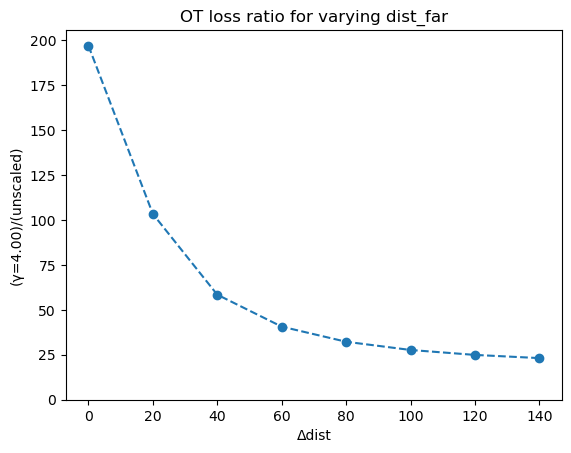

In [155]:
### Graphing Results ###
dist_far_ratios = np.asarray(target_dists_far) - ref_dist_far
dist_far_ot_ratios = np.asarray(dist_far_ot_scaled)/np.asarray(dist_far_ot_unscaled)

plt.plot(dist_far_ratios, dist_far_ot_ratios, marker="o", linestyle="--")
plt.xlabel("Δdist")
plt.ylabel(f"(γ={g:.2f})/(unscaled)")
plt.ylim(bottom=0)
plt.title("OT loss ratio for varying dist_far")

## Three point clouds

### Shifting the second point cloud
Two point clouds tests have proven to be unpredictable. My hypothesis here is that, due to the data being normalized by sum, a reference where data is centered around the major diagonal will barely change in terms of mass distribution, still making transportation of the major diagonal dominate. Here, we'll define a reference map with two cloud: one near the major diagonal and one on the extreme end. Then, we'll transport this map to maps with a third point cloud. My hypothesis is that here, the desired effect of having increasing distance from the major diagonal will occur.

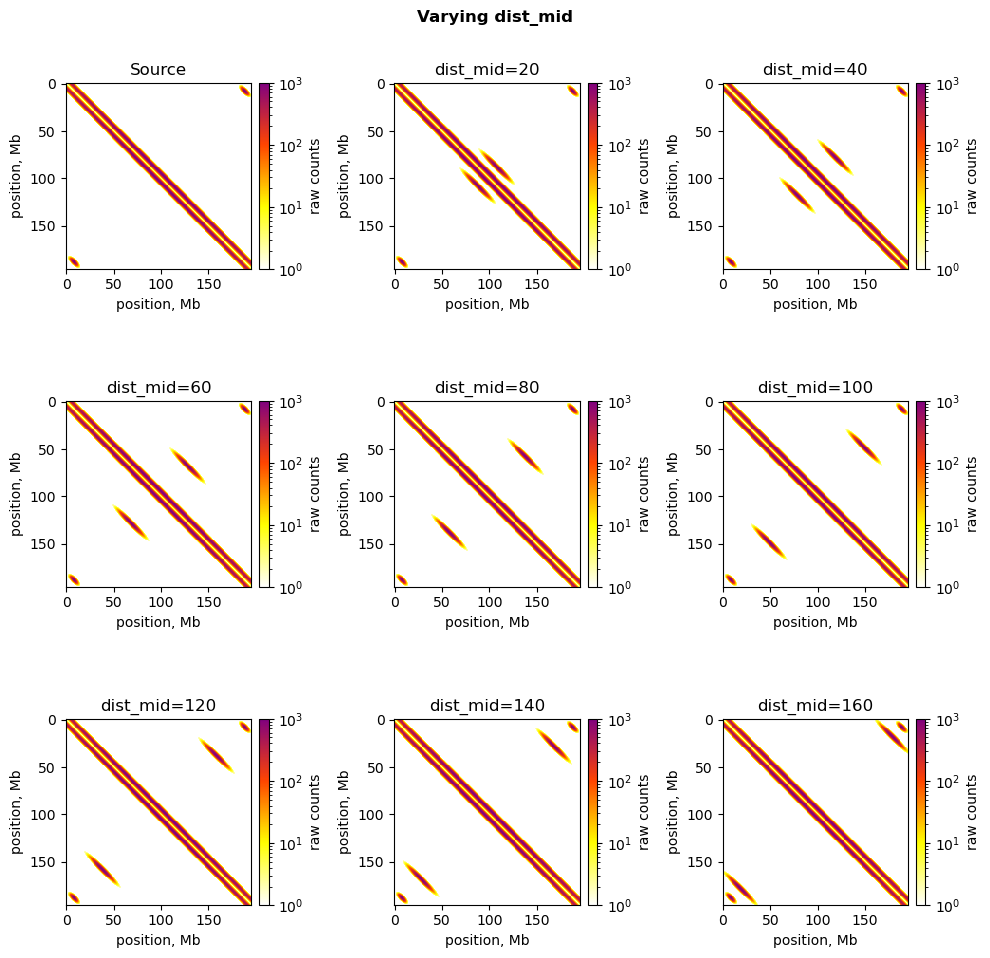

In [156]:
    # Settings parameters
n = 196
dist_near = 5
dist_far = 180
w_near = 200
w_mid = 15
w_far = 5
g = 2

spacing = np.linspace(20, 160, 8)
target_dists_mid = np.round(spacing)

    # Generating reference
near_map = generate_single_cloud_matrix(size=n, dist=dist_near, width=w_near)
far_map = generate_single_cloud_matrix(size=n, dist=dist_far, width=w_far)
ref_map = near_map + far_map

    # Visualizing
fig, axs = plt.subplots(3, 3, figsize=(10, 10))

axes_flatten = axs.flatten()
hic_vis_matrix(ref_map, f"Source", cmap="higlass", ax=axes_flatten[0])

target_maps = []
for ax, d in zip(axes_flatten[1:], target_dists_mid):
    target_map = ref_map + generate_single_cloud_matrix(size=n, dist=d, width=w_mid)
    hic_vis_matrix(target_map, f"dist_mid={d:.0f}", cmap="higlass", ax=ax)
    target_maps.append(target_map)

plt.suptitle("Varying dist_mid", fontweight="bold")
plt.tight_layout()

In [157]:
### Performing OT ###
    # Unscaled
dist_mid_ot_unscaled = hic_ot_source_to_targets(ref_map, target_maps, norm='sum')

    # Distance scaled
scaled_maps = []
scaled_ref = dist_weights(ref_map, gamma=g)
for map in target_maps:
    scaled_maps.append(dist_weights(map, gamma=g))
dist_mid_ot_scaled = hic_ot_source_to_targets(scaled_ref, scaled_maps, norm='sum')
print(dist_mid_ot_unscaled)
print(dist_mid_ot_scaled)

[57.07748363912938, 87.07893034749353, 149.50129184560478, 244.35069397721938, 371.63677985847374, 531.3909842407505, 723.6287729451251, 947.8082807665788]
[418.26489767828014, 1166.970043374476, 1682.7653591616688, 1767.5561330058492, 1509.9948065453798, 1083.7647336174027, 664.8082465254136, 388.5845299559479]


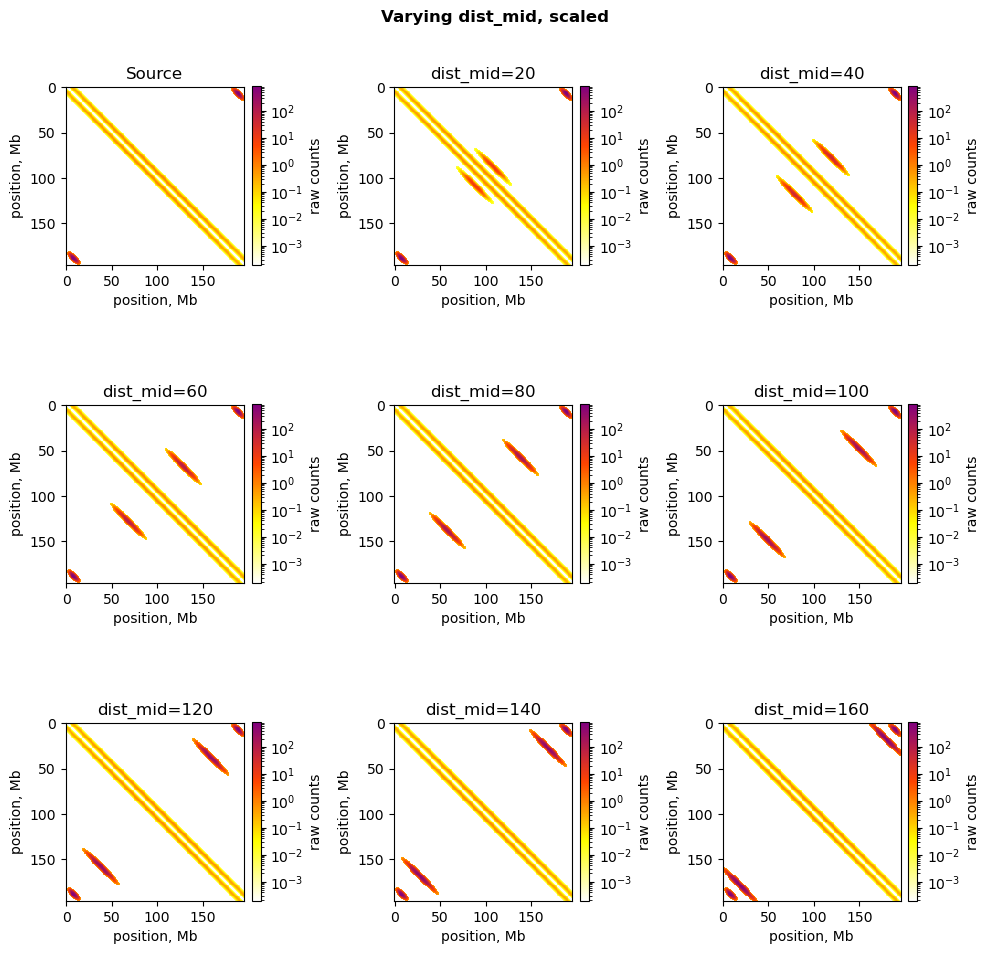

In [158]:
### Graphing scaled maps ###
fig, axs = plt.subplots(3, 3, figsize=(10, 10))

axes_flatten = axs.flatten()
hic_vis_matrix(scaled_ref, f"Source", cmap="higlass", ax=axes_flatten[0])

for ax, map, d in zip(axes_flatten[1:], scaled_maps, target_dists_mid):
    hic_vis_matrix(map, f"dist_mid={d:.0f}", cmap="higlass", ax=ax)
    target_maps.append(target_map)

plt.suptitle("Varying dist_mid, scaled", fontweight="bold")
plt.tight_layout()

Text(0.5, 1.0, 'OT loss ratio for varying dist_mid')

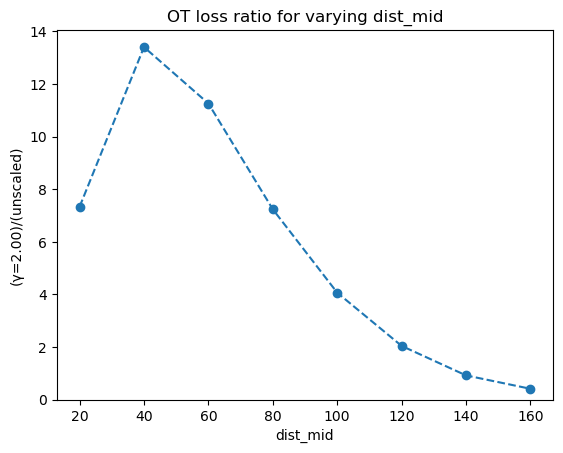

In [159]:
### Graphing Results ###
dist_mid_ratios = np.asarray(target_dists_mid)
dist_mid_ot_ratios = np.asarray(dist_mid_ot_scaled)/np.asarray(dist_mid_ot_unscaled)

plt.plot(dist_mid_ratios, dist_mid_ot_ratios, marker="o", linestyle="--")
plt.xlabel("dist_mid")
plt.ylabel(f"(γ={g:.2f})/(unscaled)")
plt.ylim(bottom=0)
plt.title("OT loss ratio for varying dist_mid")